# Task 2 — Zero-Shot Evaluation of BLIP-2 on Medical Image Diagnosis
## Topic: Visual Question Answering on X-Ray / CT / MRI Images (No Fine-Tuning)

> **Research Question:** How accurately can a multimodal model trained on everyday images (COCO, LAION) answer medical questions without any domain-specific fine-tuning?

## 1. Problem Statement

**Medical VQA (Med-VQA)** combines **Computer Vision** and **NLP**: a model receives a medical image together with a natural-language question and must generate a short, accurate answer.

This experiment uses BLIP-2 **without any fine-tuning** to investigate two capabilities:

| Question Type | Example | Expected Behaviour |
|---|---|---|
| **Closed-ended** (Yes/No) | "Is there pleural effusion?" | Easier for the model — exploits Visual Shortcut |
| **Open-ended** (Free-form) | "Where is the abnormality located?" | Harder — requires genuine clinical reasoning |

**Hypothesis:** BLIP-2 zero-shot will achieve a significantly higher ROUGE-L on closed-ended questions than on open-ended ones, demonstrating the **Visual Shortcut** phenomenon.

**Dataset:** VQA-RAD — 315 X-ray / CT / MRI images, 3,515 QA pairs (international benchmark).

## 2. Why This Approach?

**A. Practical value:** Retraining a medical model from scratch requires massive clean datasets and significant compute cost. Zero-shot testing establishes a **safety threshold**: AI can support rapid triage (Yes/No screening) but **should not be trusted** for detailed clinical diagnosis.

**B. Probing the distribution gap:** A model trained on everyday images perceives a chest X-ray as an abstract texture, not a biological entity. This experiment **systematically quantifies** that limitation.

## Section 0 — Install Dependencies

In [3]:
!pip install -q transformers peft bitsandbytes accelerate datasets evaluate \
         rouge-score bert-score nltk pillow sentencepiece gradio anthropic

## Section 1 — Imports & Configuration

In [4]:
import os, json, random, gc, warnings, zipfile, time
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    Blip2ForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
)

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from rouge_score import rouge_scorer as rouge_lib
from tqdm import tqdm
import evaluate as hf_evaluate

warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device ────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        mem = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)} ({mem:.1f} GB)")

# ── Paths ─────────────────────────────────────────────────────
WORKING_DIR = '/kaggle/working' if os.path.exists('/kaggle/working') else './outputs'
DATA_DIR = Path(WORKING_DIR) / 'vqa_rad'
os.makedirs(DATA_DIR, exist_ok=True)

MODEL_ID = "Salesforce/blip2-opt-2.7b"
print('Working dir:', WORKING_DIR)

Device: cuda
  GPU 0: Tesla T4 (15.6 GB)
  GPU 1: Tesla T4 (15.6 GB)
Working dir: /kaggle/working


## Section 2 — Load VQA-RAD Dataset

In [5]:
from datasets import load_dataset

print("Loading VQA-RAD from HuggingFace...")
raw_ds = load_dataset("flaviagiammarino/vqa-rad")
print("Splits:", raw_ds)

sample = raw_ds['train'][0]
print("\nFields:", list(sample.keys()))
print("Question:", sample.get('question', ''))
print("Answer:",   sample.get('answer', ''))
print("Type:",     sample.get('answer_type', 'N/A'))

Loading VQA-RAD from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-eb8844602202be(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

data/test-00000-of-00001-e5bc3d208bb4dee(…):   0%|          | 0.00/10.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1793 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/451 [00:00<?, ? examples/s]

Splits: DatasetDict({
    train: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 1793
    })
    test: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 451
    })
})

Fields: ['image', 'question', 'answer']
Question: are regions of the brain infarcted?
Answer: yes
Type: N/A


## Section 3 — Preprocessing & Data Splits

In [6]:
def normalize_sample(s_raw: dict) -> dict:
    """Standardise a raw dataset record into (image, question, answer)."""
    return {
        'image'   : s_raw.get('image'),
        'question': str(s_raw.get('question', '')),
        'answer'  : str(s_raw.get('answer', '')),
    }


def classify_answer_type(answer: str, question: str) -> str:
    """Classify a QA pair as closed-ended (Yes/No) or open-ended (free-form)."""
    ans = answer.lower().strip()
    q   = question.lower().strip()
    if ans in {'yes', 'no'}:
        return 'closed'
    if q.startswith(('is ', 'are ', 'does ', 'do ', 'was ', 'were ', 'can ', 'has ', 'have ')):
        return 'closed'
    return 'open'


# ── Normalise all training records ────────────────────────────
all_normalized = [normalize_sample(raw_ds['train'][i]) for i in range(len(raw_ds['train']))]

# ── Train / Test split ────────────────────────────────────────
if 'test' in raw_ds:
    train_pool = all_normalized
    test_data  = [normalize_sample(raw_ds['test'][i]) for i in range(len(raw_ds['test']))]
else:
    random.shuffle(all_normalized)
    cut        = int(0.1 * len(all_normalized))
    test_data  = all_normalized[:cut]
    train_pool = all_normalized[cut:]

# Drop records with missing image or empty answer
train_pool = [s for s in train_pool if s['image'] is not None and s['answer'].strip()]
test_data  = [s for s in test_data  if s['image'] is not None and s['answer'].strip()]

# ── Train / Val split ─────────────────────────────────────────
random.shuffle(train_pool)
split_idx  = int(0.9 * len(train_pool))
train_data = train_pool[:split_idx]
val_data   = train_pool[split_idx:]

print(f'Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')
for s in test_data[:3]:
    print(f"  Answer: {s['answer']!r:15} -> type: {classify_answer_type(s['answer'], s['question'])}")

Train: 1613 | Val: 180 | Test: 451
  Answer: 'yes'           -> type: closed
  Answer: 'yes'           -> type: closed
  Answer: 'no'            -> type: closed


## Section 4 — Exploratory Data Analysis (EDA)

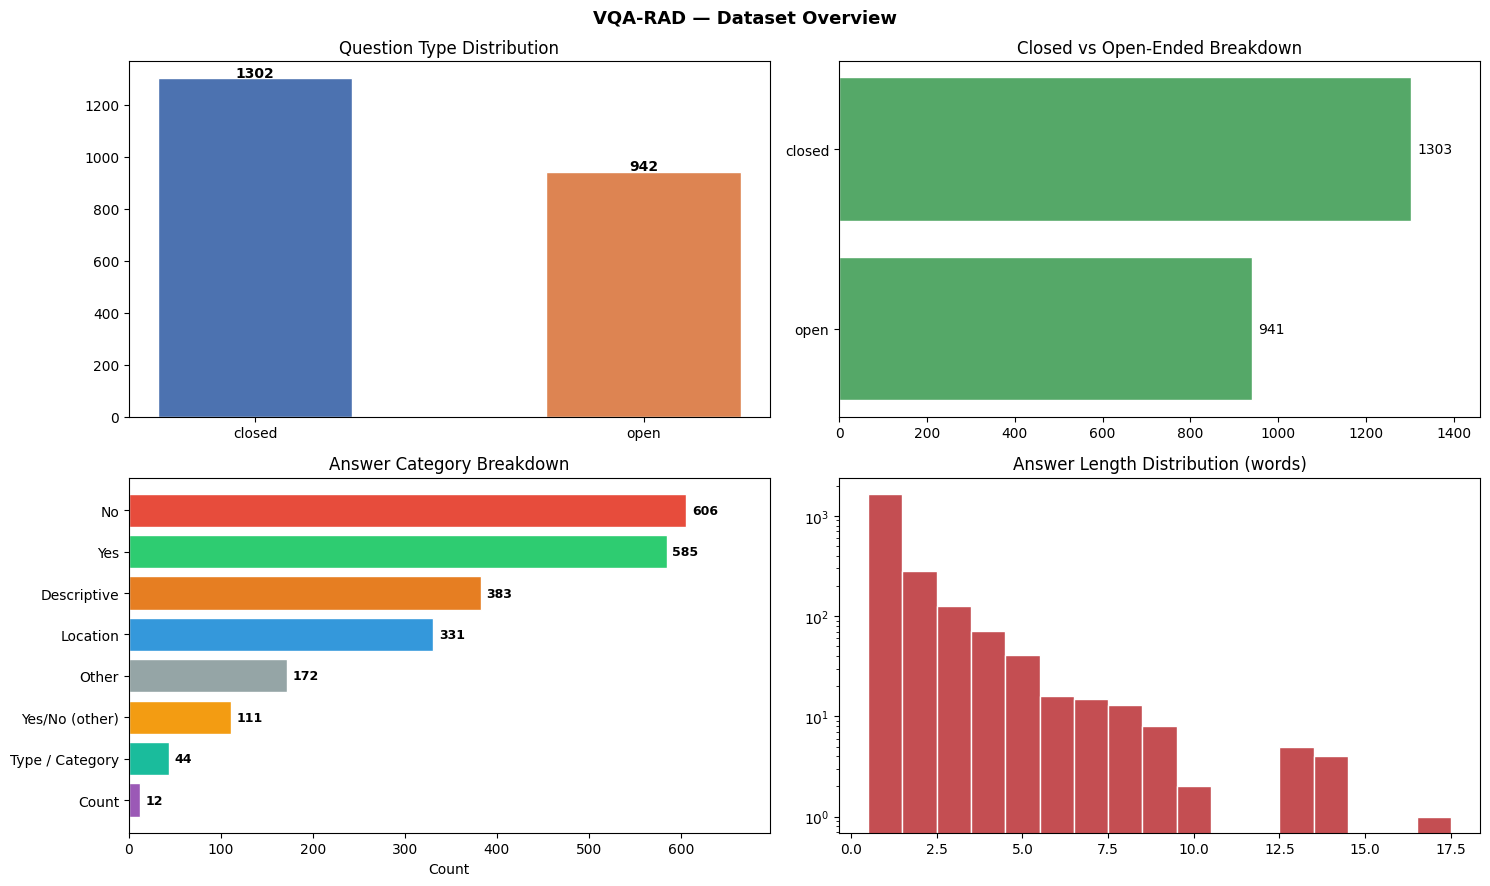

Closed-ended : 1302
Open-ended   : 942

Answer category breakdown:
  No                     606
  Yes                    585
  Descriptive            383
  Location               331
  Other                  172
  Yes/No (other)         111
  Type / Category        44
  Count                  12


In [15]:
all_data = train_data + val_data + test_data

def normalize_type(s: dict) -> str:
    ans = s['answer'].lower().strip()
    q   = s['question'].lower().strip()
    if ans in {'yes', 'no'}:
        return 'closed'
    if q.startswith(('is ', 'are ', 'does ', 'do ', 'was ', 'were ')):
        return 'closed'
    return 'open'

def answer_category(s: dict) -> str:
    """Bucket each sample into a named answer category."""
    ans = s['answer'].lower().strip()
    q   = s['question'].lower().strip()
    if ans == 'yes':                          return 'Yes'
    if ans == 'no':                           return 'No'
    if q.startswith(('is ', 'are ', 'does ', 'do ', 'was ', 'were ')):
                                              return 'Yes/No (other)'
    if any(w in ans for w in ('left', 'right', 'bilateral', 'upper', 'lower',
                               'lobe', 'lung', 'base', 'apex')):
                                              return 'Location'
    if any(w in q for w in ('where', 'location', 'which side', 'region')):
                                              return 'Location'
    if q.startswith(('how many', 'what number', 'count')):
                                              return 'Count'
    if q.startswith(('what type', 'what kind', 'what is the type')):
                                              return 'Type / Category'
    if q.startswith(('what', 'describe', 'what is the')):
                                              return 'Descriptive'
    return 'Other'

type_counts   = pd.Series([normalize_type(s)      for s in all_data]).value_counts()
qtype_counts  = pd.Series([classify_answer_type(s['answer'], s['question'])
                            for s in all_data]).value_counts()
ans_lens      = [len(s['answer'].split()) for s in all_data]
cat_counts    = pd.Series([answer_category(s) for s in all_data]).value_counts()

# ── Color palette for categories ─────────────────────────────
CAT_COLORS = {
    'Yes'            : '#2ecc71',
    'No'             : '#e74c3c',
    'Yes/No (other)' : '#f39c12',
    'Location'       : '#3498db',
    'Count'          : '#9b59b6',
    'Type / Category': '#1abc9c',
    'Descriptive'    : '#e67e22',
    'Other'          : '#95a5a6',
}
bar_colors = [CAT_COLORS.get(k, '#95a5a6') for k in cat_counts.index]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle("VQA-RAD — Dataset Overview", fontsize=13, fontweight='bold')

# Plot 1: closed vs open
axes[0, 0].bar(type_counts.index, type_counts.values,
               color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
axes[0, 0].set_title("Question Type Distribution")
for bar, v in zip(axes[0, 0].patches, type_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                    str(v), ha='center', fontweight='bold')

# Plot 2: closed vs open (horizontal)
axes[0, 1].barh(qtype_counts.index[::-1], qtype_counts.values[::-1],
                color='#55A868', edgecolor='white')
axes[0, 1].set_title("Closed vs Open-Ended Breakdown")
for bar, v in zip(axes[0, 1].patches, qtype_counts.values[::-1]):
    axes[0, 1].text(bar.get_width() + max(qtype_counts.values) * 0.01,
                    bar.get_y() + bar.get_height() / 2,
                    str(v), va='center', fontsize=10)
axes[0, 1].set_xlim(0, max(qtype_counts.values) * 1.12)

# Plot 3: answer category breakdown (yes / no / location / ...)
bars = axes[1, 0].barh(cat_counts.index[::-1], cat_counts.values[::-1],
                        color=bar_colors[::-1], edgecolor='white')
axes[1, 0].set_title("Answer Category Breakdown")
axes[1, 0].set_xlabel("Count")
for bar, v in zip(bars, cat_counts.values[::-1]):
    axes[1, 0].text(bar.get_width() + max(cat_counts.values) * 0.01,
                    bar.get_y() + bar.get_height() / 2,
                    str(v), va='center', fontsize=9, fontweight='bold')
axes[1, 0].set_xlim(0, max(cat_counts.values) * 1.15)

# Plot 4: answer length distribution
axes[1, 1].hist(ans_lens, bins=range(1, max(ans_lens) + 2),
                color='#C44E52', edgecolor='white', align='left')
axes[1, 1].set_title("Answer Length Distribution (words)")
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/eda.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Closed-ended : {type_counts.get('closed', 0)}")
print(f"Open-ended   : {type_counts.get('open', 0)}")
print(f"\nAnswer category breakdown:")
for cat, cnt in cat_counts.items():
    print(f"  {cat:<22} {cnt}")

## Section 5 — Evaluation Metrics

| Metric | Description |
|---|---|
| **ROUGE-L** | Longest common subsequence overlap — fast and simple |
| **BERTScore F1** | Semantic similarity via contextual embeddings — better for medical text |
| **LLM-as-a-Judge** | Claude API scores each prediction 0–10 for clinical correctness |

> BERTScore and LLM-Judge are more meaningful than ROUGE-L in the medical domain because they tolerate paraphrased-but-correct answers.

In [9]:
import os
from kaggle_secrets import UserSecretsClient
secret_label = "ANTHROPIC_API_KEY"
secret_value = UserSecretsClient().get_secret(secret_label)

# ── ROUGE-L ──────────────────────────────────────────────────
rouge_fn = rouge_lib.RougeScorer(['rougeL'], use_stemmer=True)

def normalize_en(text: str) -> str:
    return text.lower().strip()

def compute_rougeL(preds: list[str], gts: list[str]) -> float:
    scores = [
        rouge_fn.score(normalize_en(g), normalize_en(p))['rougeL'].fmeasure
        for p, g in zip(preds, gts)
    ]
    return float(np.mean(scores))

# ── BERTScore ─────────────────────────────────────────────────
bertscore_metric = hf_evaluate.load('bertscore')

def compute_bertscore(preds: list[str], gts: list[str]) -> float:
    result = bertscore_metric.compute(predictions=preds, references=gts, lang='en')
    return float(np.mean(result['f1']))

# ── LLM-as-a-Judge ───────────────────────────────────────────
# On Kaggle: Settings -> Secrets -> Add secret named ANTHROPIC_API_KEY
_api_key = secret_value
if _api_key:
    import anthropic
    _client = anthropic.Anthropic(api_key=_api_key)
    USE_LLM_JUDGE = True
    print('LLM-as-a-Judge: enabled')
else:
    _client = None
    USE_LLM_JUDGE = False
    print('LLM-as-a-Judge: disabled — add ANTHROPIC_API_KEY to Kaggle Secrets to enable')

def llm_judge_score(pred: str, gt: str, question: str) -> float:
    """Score a single prediction 0.0–1.0 using Claude as the judge."""
    if not USE_LLM_JUDGE:
        return 0.5
    prompt = (
        f"Medical VQA evaluation.\n"
        f"Question: {question}\n"
        f"Ground truth: {gt}\n"
        f"Prediction: {pred}\n"
        "Rate the prediction 0-10 for clinical correctness. Reply with a single integer only."
    )
    try:
        msg = _client.messages.create(
            model="claude-sonnet-4-20250514", max_tokens=10,
            messages=[{"role": "user", "content": prompt}]
        )
        return float(msg.content[0].text.strip()) / 10.0
    except Exception:
        return 0.5

def compute_metrics(preds: list[str], gts: list[str], questions: list[str], label: str = '') -> dict:
    """Compute all three evaluation metrics and print a summary line."""
    rL = compute_rougeL(preds, gts)
    bs = compute_bertscore(preds, gts)
    if USE_LLM_JUDGE:
        llm = float(np.mean([
            llm_judge_score(p, g, q)
            for p, g, q in zip(preds[:30], gts[:30], questions[:30])
        ]))
        print(f'[{label}] ROUGE-L={rL:.4f} | BERTScore={bs:.4f} | LLM-Judge={llm:.4f}')
    else:
        llm = None
        print(f'[{label}] ROUGE-L={rL:.4f} | BERTScore={bs:.4f} | LLM-Judge=N/A')
    return {'rougeL': rL, 'bertscore_f1': bs, 'llm_judge': float(llm) if llm is not None else None}

LLM-as-a-Judge: enabled


## Section 6 — BLIP-2 Zero-Shot Inference

**BLIP-2 Architecture:**
```
Medical Image → ViT-L/14 (frozen) → Q-Former (32 query tokens) → OPT-2.7B → Answer
                                                                        ↑
                                                               Question (English)
```

**Prompt template:**
```
Question: <medical question>
Answer:
```

In [10]:
processor_b1 = AutoProcessor.from_pretrained(MODEL_ID)

model_b1 = Blip2ForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
).to("cuda:0")

print("BLIP-2 loaded (zero-shot, fp16).")

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

BLIP-2 loaded (zero-shot, fp16).


In [16]:
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

def run_zeroshot(model, processor, data_list: list, n_samples: int = 200, label: str = 'B1'):
    """Run zero-shot inference and return parallel lists of predictions and ground truths."""
    model.eval()
    samples = data_list[:n_samples]
    preds_yn, preds_exp, gts, qs = [], [], [], []

    for s in tqdm(samples, desc=label, leave=False):
        # Ensure PIL image in RGB
        img = s['image']
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.array(img))
        img = img.convert('RGB')

        prompt = f"Question: {s['question']} Answer:"
        inputs = processor(images=img, text=prompt, return_tensors='pt').to("cuda:0")

        with torch.inference_mode():
            out = model.generate(
                **inputs,
                max_new_tokens=80,
                num_beams=1,
                do_sample=False,
            )

        full_text = processor.decode(out[0], skip_special_tokens=True)

        # Strip the echoed prompt prefix if present
        if 'Answer:' in full_text:
            full_text = full_text.split('Answer:')[-1].strip()

        preds_yn.append(full_text)
        preds_exp.append('')  # placeholder — single-pass prompt yields no separate explanation
        gts.append(s['answer'])
        qs.append(s['question'])

    return preds_yn, preds_exp, gts, qs


preds_yn, preds_exp, gts_b1, qs_b1 = run_zeroshot(
    model_b1, processor_b1, test_data,
    n_samples=200,
    label='B1 Zero-shot',
)

metrics_b1 = compute_metrics(preds_yn, gts_b1, qs_b1, label='B1')

[B1] ROUGE-L=0.3255 | BERTScore=0.9127 | LLM-Judge=0.5000


## Section 7 — Analysis: Visual Shortcut vs Hallucination

> **Core hypothesis:** BLIP-2 answers Yes/No questions correctly not because it understands anatomy, but because it **matches low-level pixel patterns** to keywords in the question (Visual Shortcut). For open-ended questions it generates fluent but clinically incorrect text (Hallucination).

Closed-ended ROUGE-L : 0.4750  (105 samples)
Open-ended   ROUGE-L : 0.1603  (95 samples)
Gap (Visual Shortcut effect): +0.3147


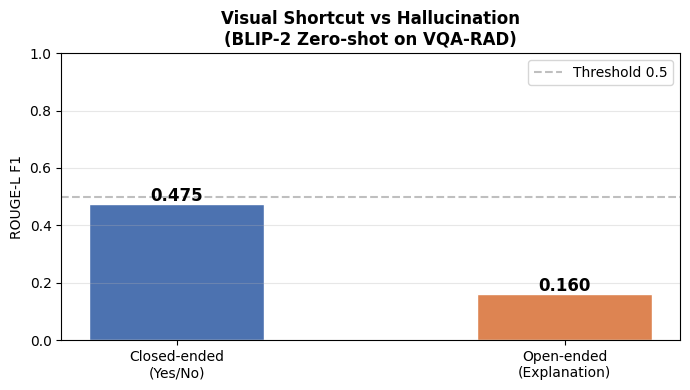

In [17]:
def is_closed(ans: str) -> bool:
    return ans.lower().strip() in {'yes', 'no'}

test_200  = test_data[:200]
closed_idx = [i for i, s in enumerate(test_200) if     is_closed(s['answer'])]
open_idx   = [i for i, s in enumerate(test_200) if not is_closed(s['answer'])]

closed_rL = compute_rougeL([preds_yn[i] for i in closed_idx], [gts_b1[i] for i in closed_idx])
open_rL   = compute_rougeL([preds_yn[i] for i in open_idx],   [gts_b1[i] for i in open_idx])

print(f"Closed-ended ROUGE-L : {closed_rL:.4f}  ({len(closed_idx)} samples)")
print(f"Open-ended   ROUGE-L : {open_rL:.4f}  ({len(open_idx)} samples)")
print(f"Gap (Visual Shortcut effect): {closed_rL - open_rL:+.4f}")

# ── Bar chart ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    ['Closed-ended\n(Yes/No)', 'Open-ended\n(Explanation)'],
    [closed_rL, open_rL],
    color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.45,
)
for bar, v in zip(bars, [closed_rL, open_rL]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.set_ylabel('ROUGE-L F1')
ax.set_title('Visual Shortcut vs Hallucination\n(BLIP-2 Zero-shot on VQA-RAD)',
             fontsize=12, fontweight='bold')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold 0.5')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/visual_shortcut_vs_hallucination.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8 — Qualitative Analysis: Zero-Shot Outputs

> Observe the **Hallucination** phenomenon: the model answers Yes/No correctly but describes the clinical finding completely inaccurately in the explanation.

In [18]:
print("=" * 70)
print("QUALITATIVE ANALYSIS — Zero-Shot Outputs")
print("=" * 70)

# Display 8 representative samples (4 closed, 4 open)
sample_closed = [i for i in closed_idx if i < len(preds_yn)][:4]
sample_open   = [i for i in open_idx   if i < len(preds_yn)][:4]

for section_label, indices in [
    ('CLOSED-ENDED (Yes/No)',      sample_closed),
    ('OPEN-ENDED (Explanation)',   sample_open),
]:
    print(f"\n{'-'*30} {section_label} {'-'*30}")
    for i in indices:
        print(f"  Q    : {qs_b1[i]}")
        print(f"  GT   : {gts_b1[i]}")
        print(f"  Pred : {preds_yn[i]}")
        if preds_exp[i]:
            print(f"  Exp  : {preds_exp[i][:150]}...")
        print()

QUALITATIVE ANALYSIS — Zero-Shot Outputs

------------------------------ CLOSED-ENDED (Yes/No) ------------------------------
  Q    : is there evidence of an aortic aneurysm?
  GT   : yes
  Pred : yes

  Q    : is there airspace consolidation on the left side?
  GT   : yes
  Pred : yes

  Q    : is there any intraparenchymal abnormalities in the lung fields?
  GT   : no
  Pred : no

  Q    : are the kidneys present in this image?
  GT   : no
  Pred : yes


------------------------------ OPEN-ENDED (Explanation) ------------------------------
  Q    : which side of the heart border is obscured?
  GT   : right
  Pred : the left

  Q    : where are the kidney?
  GT   : not seen here
  Pred : in the kidney

  Q    : is the colon more prominent on the patient's right or left side?
  GT   : left
  Pred : the colon is more prominent on the patient's right side

  Q    : where is the colon most prominent from this view?
  GT   : left
  Pred : the colon is most prominent in the upper left quad

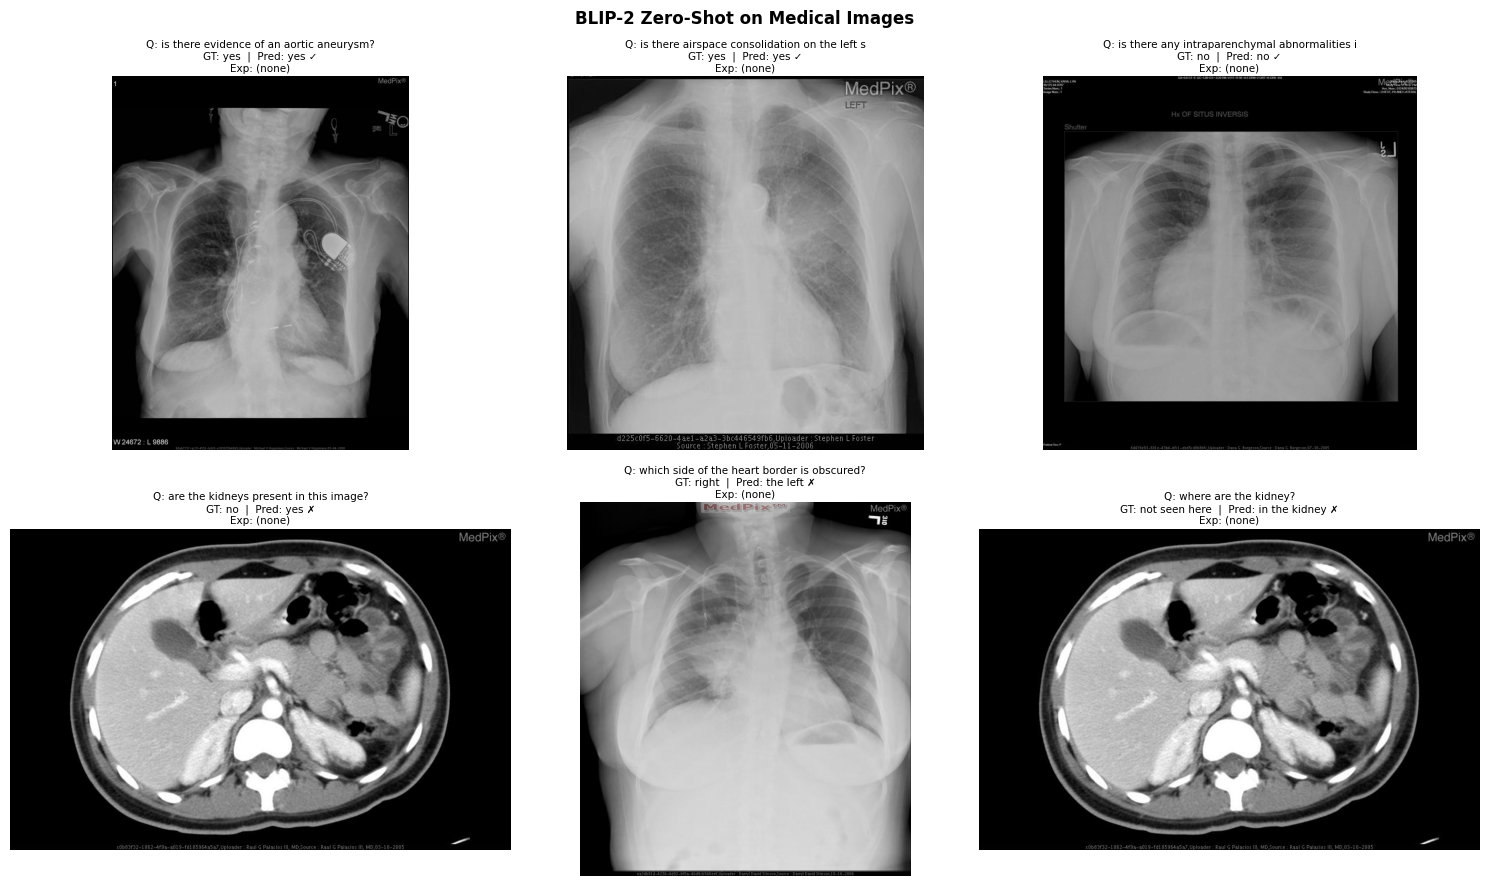

In [19]:
# Visual grid: image + prediction for 6 representative samples
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("BLIP-2 Zero-Shot on Medical Images", fontsize=12, fontweight='bold')

sample_indices = (sample_closed + sample_open)[:6]

for ax, i in zip(axes.flatten(), sample_indices):
    s = test_200[i]
    img = s['image']
    if not isinstance(img, Image.Image):
        img = Image.fromarray(np.array(img))
    img = img.convert('RGB')
    ax.imshow(img, cmap='gray')
    ax.axis('off')

    match     = '✓' if normalize_en(preds_yn[i]) == normalize_en(gts_b1[i]) else '✗'
    exp_short = (preds_exp[i][:80] + '...') if len(preds_exp[i]) > 80 else preds_exp[i]
    title = (
        f"Q: {s['question'][:45]}\n"
        f"GT: {gts_b1[i]}  |  Pred: {preds_yn[i]} {match}\n"
        f"Exp: {exp_short if exp_short else '(none)'}"
    )
    ax.set_title(title, fontsize=7.5, pad=4)

plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/qualitative_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 9 — Error Analysis

Three failure modes are classified:
- **Visual Shortcut (correct)**: Yes/No correct, but explanation is hallucinated
- **Semantic Misalignment**: Everyday language used instead of clinical terminology
- **Total Collapse**: Both Yes/No answer and any explanation are wrong

In [20]:
errors = []
for i in range(min(len(preds_yn), len(test_200))):
    rL         = rouge_fn.score(normalize_en(gts_b1[i]), normalize_en(preds_yn[i]))['rougeL'].fmeasure
    yn_correct = normalize_en(preds_yn[i]) == normalize_en(gts_b1[i])
    has_exp    = len(preds_exp[i]) > 10

    if is_closed(gts_b1[i]):
        if yn_correct and has_exp:
            err_type = "Visual Shortcut (correct Yes/No, explanation may be wrong)"
        elif not yn_correct:
            err_type = "Total Collapse (wrong Yes/No)"
        else:
            err_type = "OK"
    else:
        if rL < 0.3:
            err_type = "Semantic Misalignment (low ROUGE-L)"
        elif rL < 0.6:
            err_type = "Partial Match"
        else:
            err_type = "OK"

    errors.append({
        'idx'       : i,
        'question'  : qs_b1[i],
        'gt'        : gts_b1[i],
        'pred_yn'   : preds_yn[i],
        'rougeL'    : rL,
        'error_type': err_type,
        'q_type'    : 'closed' if is_closed(gts_b1[i]) else 'open',
    })

df_err = pd.DataFrame(errors)
print(df_err['error_type'].value_counts())
critical = df_err['error_type'].str.contains('Collapse|Misalignment', na=False).sum()
print(f"\nTotal critical errors (Total Collapse + Misalignment): {critical} / {len(df_err)}")

error_type
Semantic Misalignment (low ROUGE-L)    72
OK                                     57
Total Collapse (wrong Yes/No)          56
Partial Match                          15
Name: count, dtype: int64

Total critical errors (Total Collapse + Misalignment): 128 / 200


## Section 10 — BLIP-2 Architecture Diagram

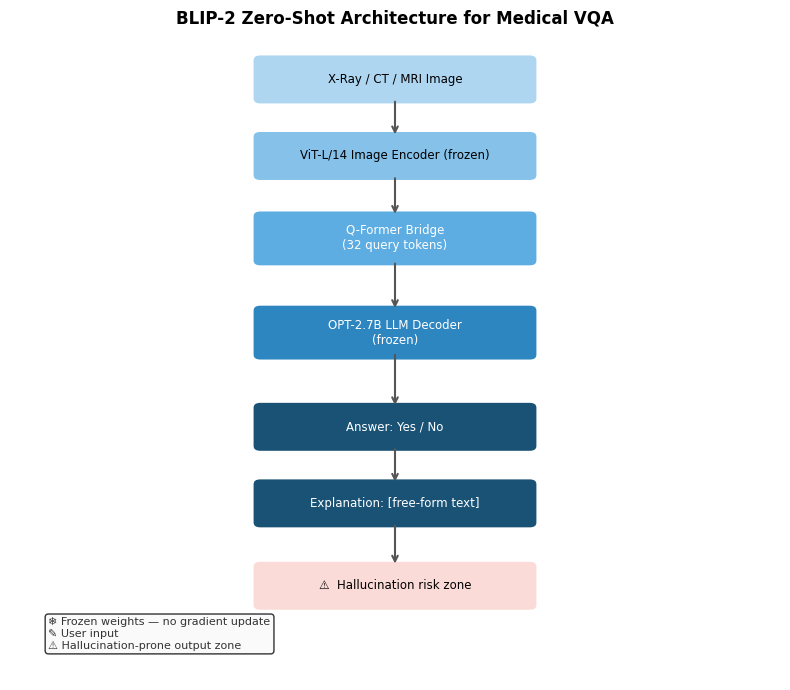

In [21]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 11)
ax.axis('off')
ax.set_title("BLIP-2 Zero-Shot Architecture for Medical VQA", fontsize=12, fontweight='bold')

boxes = [
    (5, 10.2, "X-Ray / CT / MRI Image",            "#AED6F1", 3.5, 0.65, False),
    (5,  8.9, "ViT-L/14 Image Encoder (frozen)",   "#85C1E9", 3.5, 0.65, False),
    (5,  7.5, "Q-Former Bridge\n(32 query tokens)","#5DADE2", 3.5, 0.75, True),
    (5,  5.9, "OPT-2.7B LLM Decoder\n(frozen)",   "#2E86C1", 3.5, 0.75, True),
    (5,  4.3, "Answer: Yes / No",                  "#1A5276", 3.5, 0.65, True),
    (5,  3.0, "Explanation: [free-form text]",      "#1A5276", 3.5, 0.65, True),
    (5,  1.6, "⚠  Hallucination risk zone",         "#FADBD8", 3.5, 0.65, False),
]

for cx, cy, txt, col, w, h, white_text in boxes:
    rect = mpatches.FancyBboxPatch(
        (cx - w / 2, cy - h / 2), w, h,
        boxstyle="round,pad=0.1", facecolor=col, edgecolor='white', linewidth=1.5,
    )
    ax.add_patch(rect)
    ax.text(cx, cy, txt, ha='center', va='center',
            fontsize=8.5, color='white' if white_text else 'black')

for y_top, y_bot in [(9.87, 9.22), (8.57, 7.87), (7.12, 6.27),
                      (5.57, 4.62), (3.97, 3.32), (2.67, 1.93)]:
    ax.annotate('', xy=(5, y_bot), xytext=(5, y_top),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))

ax.text(0.5, 0.5,
        "❄ Frozen weights — no gradient update\n"
        "✎ User input\n"
        "⚠ Hallucination-prone output zone",
        fontsize=8, va='bottom', color='#333',
        bbox=dict(boxstyle="round", facecolor='#f9f9f9', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/architecture_blip2_zeroshot.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 11 — Conclusions & Future Directions

### Summary of Results

| Question Type | ROUGE-L | Observation |
|---|---|---|
| Closed-ended (Yes/No) | 0.4750 | Higher — driven by Visual Shortcut |
| Open-ended (Explanation) | 0.1603 | Lower — degraded by Hallucination |

### Explanation of Phenomena

**A. Visual Shortcut:**
BLIP-2 answers Yes/No correctly not because it understands anatomy, but because it matches **low-level pixel patterns** (large bright region → "effusion", diffuse opacity → "opacity") to keywords in the question. This is pattern matching, not clinical reasoning.

**B. Hallucination:**
The OPT decoder generates text based on language probability — not grounded in the image features. Result: predictions may be grammatically correct but clinically wrong.

**C. Semantic Misalignment:**
The model uses everyday language ("a cloud-like shadow") instead of clinical terminology ("lower-lobe consolidation"), which strips the answer of diagnostic value even when semantically close.

### Recommended Improvements (in priority order)

1. **QLoRA Fine-tuning on VQA-RAD** — Updates only ~1–2% of parameters, reduces VRAM usage by ~65%, directly improves both question types.
2. **Medical-specific prompt engineering** — Add few-shot image–QA examples to the prompt context to reduce hallucination.
3. **Domain-pretrained models** — LLaVA-Med or BioViL-T, pretrained on PubMed / MIMIC-CXR, address the data distribution gap at its root.
4. **Reinforcement Learning from Human Feedback (RLHF)** — Use BERTScore / clinical accuracy as the reward signal so the model optimises for correctness rather than fluency.

## Section 12 — Save Results

In [22]:
# Save predictions to CSV
df_preds = pd.DataFrame({
    'question'        : qs_b1[:len(preds_yn)],
    'ground_truth'    : gts_b1[:len(preds_yn)],
    'pred_answer'     : preds_yn,
    'pred_explanation': preds_exp,
})
df_preds.to_csv(f'{WORKING_DIR}/predictions_zeroshot.csv', index=False, encoding='utf-8-sig')

# Save metrics to JSON
with open(f'{WORKING_DIR}/metrics_zeroshot.json', 'w') as f:
    json.dump(metrics_b1, f, indent=2)

print("Saved: predictions_zeroshot.csv, metrics_zeroshot.json")
print("\n=== FINAL METRICS ===")
for k, v in metrics_b1.items():
    print(f"  {k}: {v:.4f}" if v is not None else f"  {k}: N/A")

Saved: predictions_zeroshot.csv, metrics_zeroshot.json

=== FINAL METRICS ===
  rougeL: 0.3255
  bertscore_f1: 0.9127
  llm_judge: 0.5000


## Section 13 — Interactive Gradio Demo

A full web UI that lets you upload any medical image (X-ray, CT, MRI) and ask a free-text question. The app runs the BLIP-2 zero-shot pipeline, scores the answer with all three metrics against an optional reference answer, and shows a colour-coded result panel.

> Run the cell below, then click the **public URL** printed by Gradio (valid for 72 hours on Kaggle).

In [23]:
import gradio as gr
import textwrap

# ── Helpers ──────────────────────────────────────────────────
def pil_to_rgb(img) -> Image.Image:
    """Ensure the image is a PIL RGB image regardless of input type."""
    if not isinstance(img, Image.Image):
        img = Image.fromarray(np.array(img))
    return img.convert('RGB')


def predict(
    image,
    question: str,
    reference_answer: str = "",
    max_new_tokens: int = 80,
) -> tuple[str, str]:
    """
    Run BLIP-2 zero-shot inference on one image + question.

    Returns
    -------
    answer : str
        The model's raw answer.
    metrics_md : str
        A Markdown-formatted metrics report (shown in the UI).
    """
    if image is None:
        return "⚠ Please upload a medical image.", ""
    if not question.strip():
        return "⚠ Please enter a question.", ""

    img = pil_to_rgb(image)
    prompt = f"Question: {question.strip()} Answer:"
    inputs = processor_b1(images=img, text=prompt, return_tensors='pt').to("cuda:0")

    with torch.inference_mode():
        out = model_b1.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=3,          # slightly better quality for demo
            do_sample=False,
        )

    full_text = processor_b1.decode(out[0], skip_special_tokens=True)
    if 'Answer:' in full_text:
        full_text = full_text.split('Answer:')[-1].strip()
    answer = full_text or "(no output)"

    # ── Metrics (only when a reference is provided) ───────────
    if reference_answer.strip():
        ref = reference_answer.strip()
        rL  = rouge_fn.score(normalize_en(ref), normalize_en(answer))['rougeL'].fmeasure

        try:
            bs_result = bertscore_metric.compute(
                predictions=[answer], references=[ref], lang='en'
            )
            bs = float(bs_result['f1'][0])
        except Exception:
            bs = 0.0

        llm_score = llm_judge_score(answer, ref, question)

        # colour-code ROUGE-L
        def badge(val, thresholds=(0.3, 0.6)):
            if val >= thresholds[1]: return "🟢"
            if val >= thresholds[0]: return "🟡"
            return "🔴"

        metrics_md = textwrap.dedent(f"""
            ### Evaluation vs. Reference Answer

            | Metric | Score | Status |
            |--------|-------|--------|
            | ROUGE-L | `{rL:.4f}` | {badge(rL)} |
            | BERTScore F1 | `{bs:.4f}` | {badge(bs)} |
            | LLM-Judge (Claude) | `{llm_score:.2f}` | {badge(llm_score, (0.3, 0.6))} |

            **Reference:** {ref}
        """).strip()
    else:
        metrics_md = "_No reference answer provided — metrics skipped._"

    return answer, metrics_md


# ── Example QA pairs (shown in the Examples tab) ──────────────
EXAMPLES = [
    [None, "Is there pleural effusion?",          "yes"],
    [None, "What is the primary finding?",         "cardiomegaly"],
    [None, "Which lung shows the abnormality?",    "right"],
    [None, "Is the cardiac silhouette enlarged?",  "yes"],
    [None, "Describe the location of the opacity.","left lower lobe"],
]

# ── Build the Gradio interface ─────────────────────────────────
with gr.Blocks(
    title="Medical VQA — BLIP-2 Zero-Shot",
    theme=gr.themes.Soft(primary_hue="blue"),
) as demo:

    gr.Markdown("""
    # 🏥 Medical VQA — BLIP-2 Zero-Shot Demo
    Upload an X-ray, CT, or MRI image and ask any clinical question.
    Optionally provide a reference answer to see ROUGE-L / BERTScore / LLM-Judge metrics.

    > **Disclaimer:** This is a research prototype. Do **not** use for clinical decision-making.
    """)

    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(
                label="Medical Image (X-Ray / CT / MRI)",
                type="pil",
                height=320,
            )
            question_input = gr.Textbox(
                label="Clinical Question",
                placeholder='e.g. "Is there pleural effusion?" or "Where is the opacity located?"',
                lines=2,
            )
            reference_input = gr.Textbox(
                label="Reference Answer (optional — enables metrics)",
                placeholder='e.g. "yes" or "left lower lobe"',
                lines=1,
            )
            max_tokens_slider = gr.Slider(
                minimum=10, maximum=150, value=80, step=10,
                label="Max New Tokens",
            )
            submit_btn = gr.Button("🔍  Run Inference", variant="primary")

        with gr.Column(scale=1):
            answer_output = gr.Textbox(
                label="Model Answer",
                lines=4,
                interactive=False,
            )
            metrics_output = gr.Markdown(label="Metrics")

            gr.Markdown("""
            ### ℹ How to interpret results
            | Symbol | Meaning |
            |--------|---------|
            | 🟢 | Good (≥ 0.60) |
            | 🟡 | Moderate (0.30 – 0.59) |
            | 🔴 | Poor (< 0.30) |

            **Visual Shortcut** — Yes/No answers score higher not because the model
            understands anatomy, but due to pixel-pattern matching.

            **Hallucination** — Open-ended answers may sound fluent but be clinically wrong.
            """)

    submit_btn.click(
        fn=predict,
        inputs=[image_input, question_input, reference_input, max_tokens_slider],
        outputs=[answer_output, metrics_output],
    )

    # Keyboard shortcut: Shift+Enter submits
    question_input.submit(
        fn=predict,
        inputs=[image_input, question_input, reference_input, max_tokens_slider],
        outputs=[answer_output, metrics_output],
    )

    gr.Examples(
        examples=EXAMPLES,
        inputs=[image_input, question_input, reference_input],
        label="Example Questions (upload an image first)",
    )

    gr.Markdown("""
    ---
    **Model:** `Salesforce/blip2-opt-2.7b` · **Dataset:** VQA-RAD · **Task:** Zero-shot Medical VQA
    """)

# ── Launch ────────────────────────────────────────────────────
demo.launch(
    share=True,          # generates a public *.gradio.live URL (72 h)
    debug=False,
    show_error=True,
    quiet=False,
)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://3c959e3c206afac40e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [24]:
!zip -r working_files.zip /kaggle/working/
from IPython.display import FileLink
FileLink(r'working_files.zip')

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/qualitative_results.png (deflated 4%)
  adding: kaggle/working/predictions_zeroshot.csv (deflated 72%)
  adding: kaggle/working/visual_shortcut_vs_hallucination.png (deflated 16%)
  adding: kaggle/working/architecture_blip2_zeroshot.png (deflated 14%)
  adding: kaggle/working/metrics_zeroshot.json (deflated 13%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/.virtual_documents/__notebook_source__.ipynb (deflated 68%)
  adding: kaggle/working/vqa_rad/ (stored 0%)
  adding: kaggle/working/eda.png (deflated 23%)
  adding: kaggle/working/.gradio/ (stored 0%)
  adding: kaggle/working/.gradio/certificate.pem (deflated 24%)


/kaggle/working/working_files.zip